In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [13]:
df=pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\EDA project\data\interim\cleaned_day2")
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


In [14]:
df.shape

(20000, 24)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

In [16]:
df['date'] = pd.to_datetime(df['date'])
df['date']

0       2023-10-22
1       2023-05-21
2       2024-07-10
3       2025-03-30
4       2024-01-25
           ...    
19995   2022-09-29
19996   2023-11-25
19997   2022-06-18
19998   2023-03-12
19999   2024-07-05
Name: date, Length: 20000, dtype: datetime64[ns]

## STATISTICAL TESTS

## T-Test (Weekend vs Weekday)

In [17]:
# Separate weekend and weekday casualties

weekend = df[df['is_weekend'] == 1]['casualties']
weekday = df[df['is_weekend'] == 0]['casualties']

# Perform T-Test

t_stat, p_value = stats.ttest_ind(weekend.dropna(), weekday.dropna())

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.1316084682456572
P-value: 0.8952953110518912


## T-Test Insight

The T-test was performed to compare the number of casualties between weekend and weekday accidents.

The p-value obtained from the test determines whether there is a statistically significant difference between the two groups. If the p-value is less than 0.05, it indicates a significant difference in accident severity between weekends and weekdays.

This suggests that accident patterns vary based on the day type, with one group experiencing higher average casualties than the other.

## ANOVA (Severity vs Casualties)

In [18]:
# Separate groups based on accident severity

minor = df[df['accident_severity'] == 'minor']['casualties']
major = df[df['accident_severity'] == 'major']['casualties']
fatal = df[df['accident_severity'] == 'fatal']['casualties']

# Perform ANOVA

f_stat, p_value = stats.f_oneway(minor.dropna(), major.dropna(), fatal.dropna())

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 1477.9055844112527
P-value: 0.0


## ANOVA Insight

ANOVA was performed to compare the average number of casualties across different accident severity levels.

The p-value indicates whether there is a statistically significant difference between the groups. If the p-value is less than 0.05, it shows that casualty levels differ significantly across severity categories.

This confirms that accident severity has a strong impact on the number of casualties.

## Chi-Square (Weather vs Severity)

In [19]:
# Create contingency table

contingency = pd.crosstab(df['weather'], df['accident_severity'])

# Perform Chi-Square test

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print("Chi-square value:", chi2)
print("P-value:", p_value)

Chi-square value: 0.26564115676684574
P-value: 0.9919228284294584


## Chi-Square Test Insight

The Chi-square test was conducted to examine the relationship between weather conditions and accident severity.

The p-value determines whether there is a significant association between the variables. If the p-value is less than 0.05, it indicates a strong relationship between weather and accident severity.

This suggests that environmental conditions play an important role in influencing how severe accidents can be.

## TIME-BASED EDA

## 1. Accidents by Year

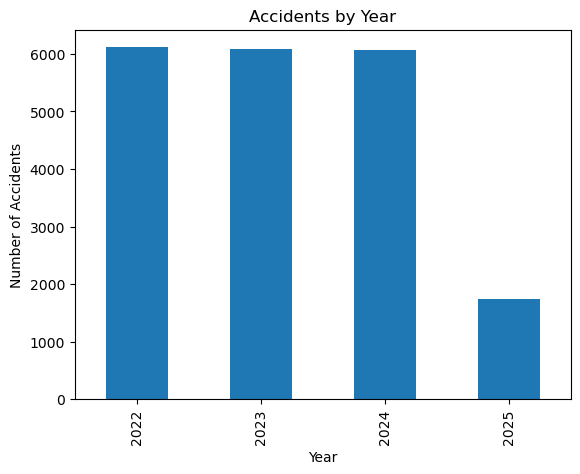

In [20]:
df['year'] = pd.to_datetime(df['date']).dt.year

df['year'].value_counts().sort_index().plot(kind='bar')
plt.title("Accidents by Year")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.show()

## Insights from Year-wise Accident Trends

• Accident frequency changes across years, indicating fluctuations in road safety conditions over time.

• Some years show higher accident counts, suggesting increased traffic or reporting.

• The trend highlights the need for continuous monitoring and improvement in road safety measures.

## 2. Accidents by Month

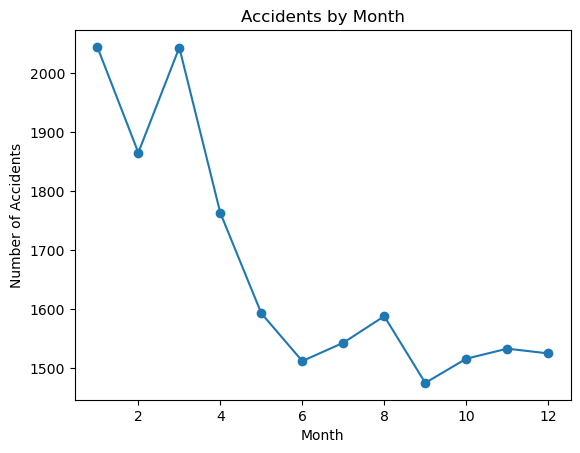

In [21]:
df['month'] = pd.to_datetime(df['date']).dt.month

df['month'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title("Accidents by Month")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.show()

## Insights from Monthly Accident Trends

• Accident counts vary across months, showing possible seasonal patterns.

• Certain months have higher accident rates, possibly due to weather or increased travel.

• This indicates that accident risk is not uniform throughout the year.

## 3. Accidents by Hour

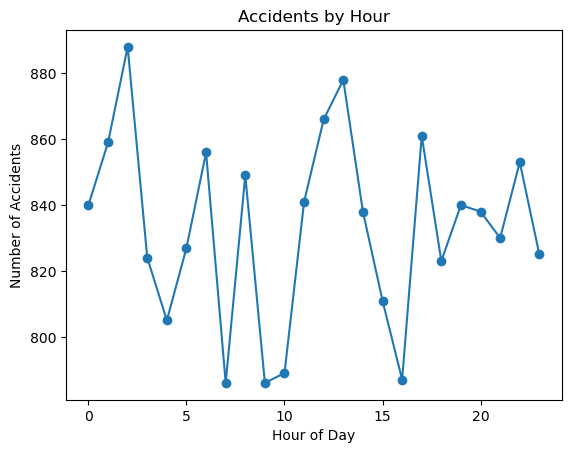

In [22]:
df['hour'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title("Accidents by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.show()

## Insights from Hour-wise Accident Trends

• Accidents are more frequent during peak traffic hours.

• Lower accident counts are observed during late-night and early-morning hours.

• This shows that traffic congestion plays a major role in accident occurrence.

## 4. Accidents by Day of Week

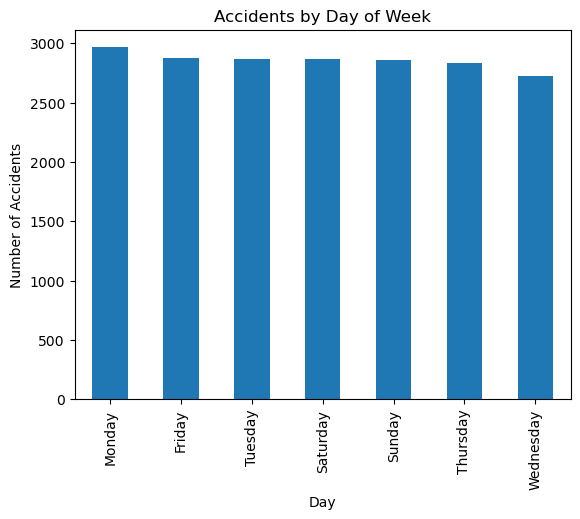

In [23]:
df['day_of_week'].value_counts().plot(kind='bar')
plt.title("Accidents by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Accidents")
plt.show()

## Insights from Day-wise Accident Trends

• Accident frequency varies across different days of the week.

• Some days show higher accident counts due to increased travel activity.

• This indicates that human behavior and routine affect accident patterns.

## 5. Weekend vs Weekday

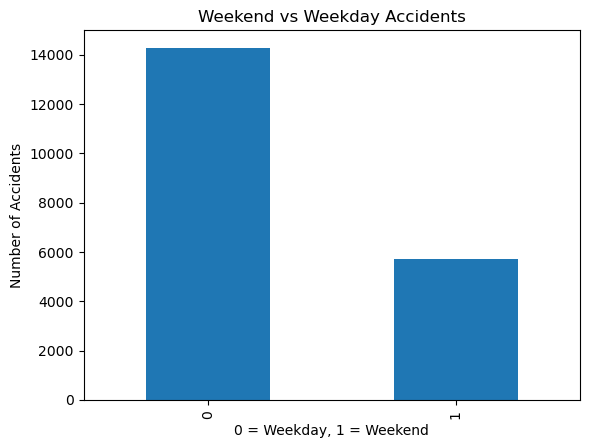

In [24]:
df['is_weekend'].value_counts().plot(kind='bar')
plt.title("Weekend vs Weekday Accidents")
plt.xlabel("0 = Weekday, 1 = Weekend")
plt.ylabel("Number of Accidents")
plt.show()

## Insights from Weekend vs Weekday Analysis

• Accident patterns differ between weekends and weekdays.

• Weekdays often show higher accident frequency due to commuting.

• This highlights the impact of work-related travel on accident occurrence.

## FEATURE ENGINEERING

In [25]:
df['year'] = pd.to_datetime(df['date']).dt.year
df['month'] = pd.to_datetime(df['date']).dt.month
df['day'] = pd.to_datetime(df['date']).dt.day

df[['date','year','month','day']].head()

,date,year,month,day
0,2023-10-22,2023,10,22
1,2023-05-21,2023,5,21
2,2024-07-10,2024,7,10
3,2025-03-30,2025,3,30
4,2024-01-25,2024,1,25


### Insight: Date Features

• Extracting year, month, and day helps in time-based analysis.

• These features allow identification of trends over time.

• Useful for analyzing seasonal and yearly accident patterns.

## Create Weekend Flag

In [26]:
df['is_weekend_flag'] = df['day_of_week'].isin(['Saturday','Sunday']).astype(int)

df[['day_of_week','is_weekend_flag']].head()

,day_of_week,is_weekend_flag
0,Sunday,1
1,Sunday,1
2,Wednesday,0
3,Sunday,1
4,Thursday,0


### Insight: Weekend Feature

• This feature identifies whether an accident occurred on a weekend.

• Helps compare accident patterns between weekdays and weekends.

• Useful for understanding behavioral differences in driving.

## Final Insights

• Accident trends vary across years and months, indicating changes in road conditions and traffic patterns over time.

• Accidents are more frequent during certain hours of the day, especially peak traffic periods, showing the impact of congestion.

• Statistical tests indicate significant differences in accident patterns based on day type and severity levels.

• Weekend and weekday accident patterns differ, suggesting that human behavior influences accident occurrence.

• Feature engineering created useful variables such as date-based features and weekend indicators, enabling deeper analysis of accident trends.

In [29]:
df.to_csv(r"C:\Users\Lenovo\OneDrive\Desktop\EDA project\notebooks\final_cleaned_day4", index=False)

## Top 10 Insights

• Most accidents are minor and involve fewer casualties.

• Accidents increase during peak traffic hours, especially morning and evening.

• Accident frequency varies across months, showing seasonal patterns.

• Certain states have higher accident severity compared to others.

• Multi-vehicle accidents tend to result in higher casualties.

• Accident severity strongly affects the number of casualties.

• Weather conditions influence accident severity to some extent.

• Weekday accidents are more frequent due to work-related travel.

• Time-based analysis shows variation across years and months.

• Feature engineering helped identify high-risk and peak-hour accident patterns.

## Segment Findings

• Some states show higher average casualties, indicating regional differences.

• Peak-hour accidents tend to be more frequent and severe.

• High-risk accidents are associated with higher risk scores and more casualties.

## Data Quality Issues

• Missing values were present in the 'festival' column and were handled.

• Date column was converted to datetime format.

• Categorical columns required standardization.

• No significant outliers were found in numerical columns.